# Customer Churn Analysis


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("Customer-Churn-Records.csv")

## 1. Understanding the dataset

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

In [9]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'Satisfaction Score', 'Card Type', 'Point Earned'],
      dtype='str')

Rows and Columns


In [10]:
df.shape

(10000, 18)

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


### Check missing values

In [12]:
df.isna().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

### Check Duplicated values

In [13]:
df.duplicated().sum()

np.int64(0)

## 2. Exploratory Data Analysis (EDA)

In [14]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [15]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [16]:
df["Card Type"].value_counts()

Card Type
DIAMOND     2507
GOLD        2502
SILVER      2496
PLATINUM    2495
Name: count, dtype: int64

## 3. Customer Churn Distribution

In [17]:
df["Exited"].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [18]:
df["Exited"].value_counts(normalize=True) * 100

Exited
0    79.62
1    20.38
Name: proportion, dtype: float64

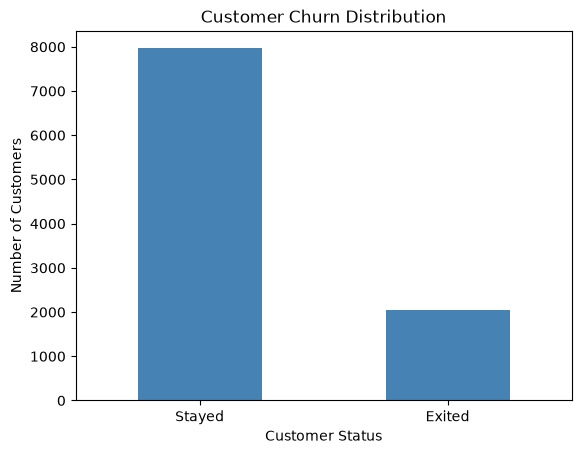

In [19]:
df["Exited"].value_counts().plot(kind="bar",color="steelblue")

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.xticks([0, 1], ["Stayed", "Exited"], rotation=0)
plt.show()

## 4. Churn Rate by Geography

In [20]:
df.groupby("Geography")["Exited"].sum()

Geography
France     811
Germany    814
Spain      413
Name: Exited, dtype: int64

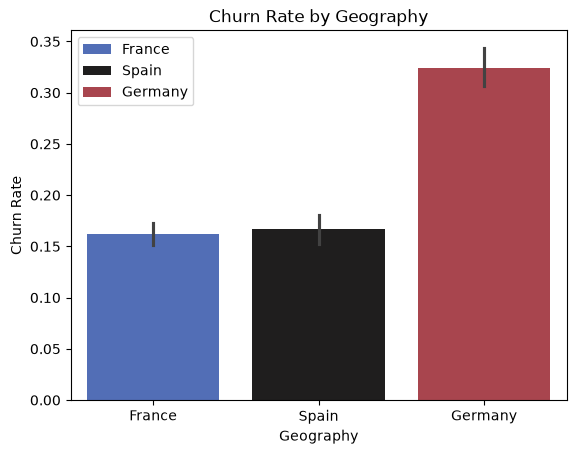

In [49]:
sns.barplot(
    data=df,
    x="Geography",
    y="Exited",
    hue="Geography",
    palette="icefire",
    legend=True
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate")
plt.legend()
plt.savefig("images/churn_by_geography.png")
plt.show()

## 5. Churn Rate by Gender

In [22]:
df.groupby("Gender")["Exited"].sum()

Gender
Female    1139
Male       899
Name: Exited, dtype: int64

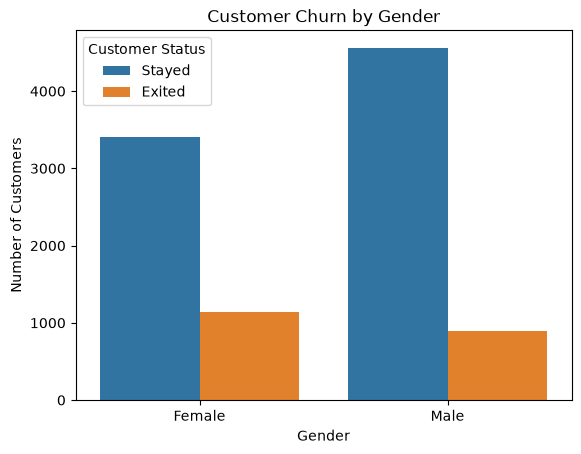

In [50]:
sns.countplot(data=df, x="Gender", hue="Exited")

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Customer Status", labels=["Stayed", "Exited"])
plt.savefig("images/churn_by_gender.png")
plt.show()

## 6. Age Distribution of Customers

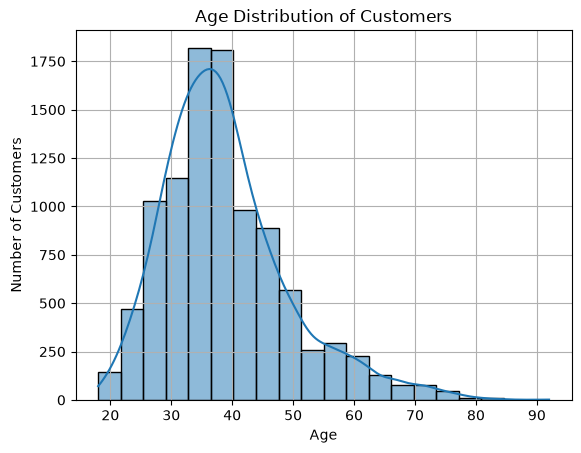

In [24]:
sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid()
plt.show()

## 7. Churn Rate by Age

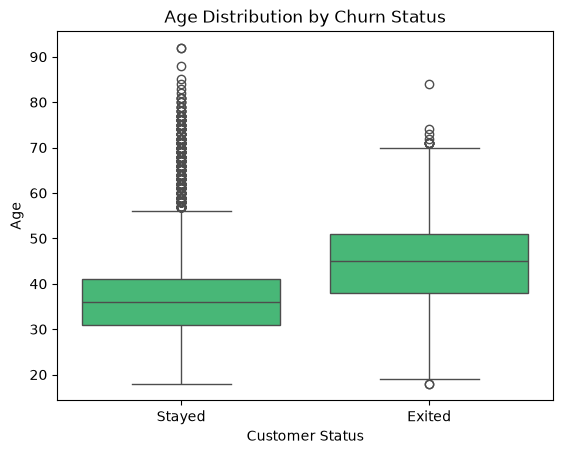

In [51]:
sns.boxplot(data=df, x="Exited", y="Age",color="#36c974")

plt.title("Age Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.savefig("images/churn_by_age.png")
plt.show()

## 8. Churn Rate by No of Products

In [26]:
df.groupby("NumOfProducts")["Exited"].mean()*100

NumOfProducts
1     27.714398
2      7.603486
3     82.706767
4    100.000000
Name: Exited, dtype: float64

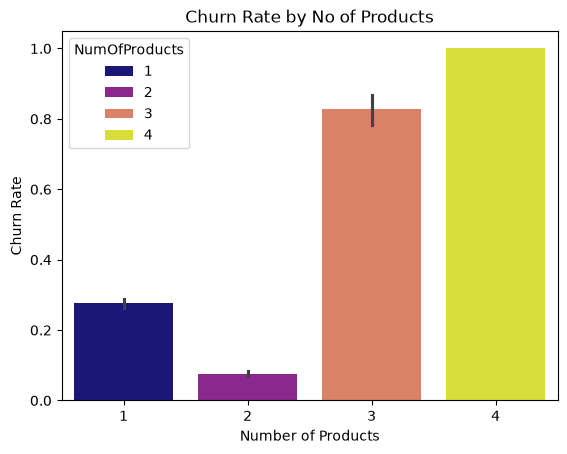

In [61]:
sns.barplot(data=df,x="NumOfProducts",y="Exited",hue="NumOfProducts", palette="plasma")
plt.title("Churn Rate by No of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate")
plt.savefig("images/churn_by_products.png")
plt.show()

## 9. Churn by Active Membership

In [28]:
df.groupby("IsActiveMember")["Exited"].mean() * 100

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64

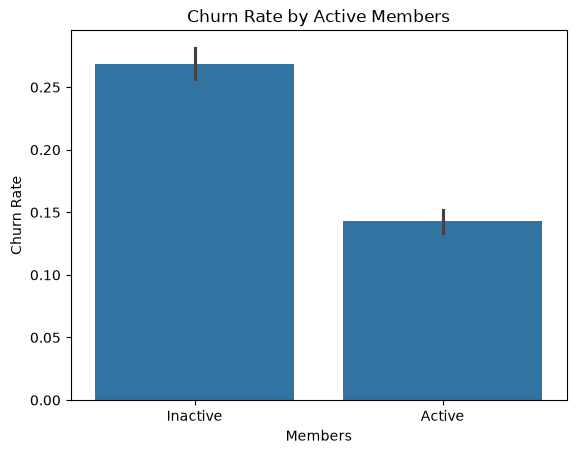

In [53]:
sns.barplot(data=df, x="IsActiveMember", y="Exited")

plt.title("Churn Rate by Active Members")
plt.xlabel("Members")
plt.ylabel("Churn Rate")
plt.xticks([0, 1], ["Inactive", "Active"])
plt.savefig("images/churn_by_active_member.png")
plt.show()

## 10. Churn by Satisfaction Score

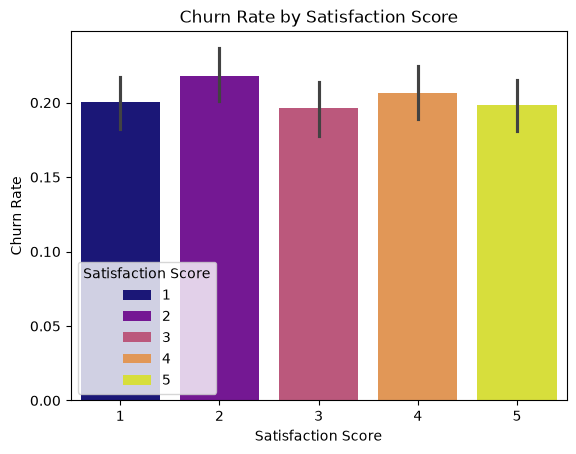

In [54]:
sns.barplot(data=df, x="Satisfaction Score", y="Exited",hue="Satisfaction Score",palette="plasma")

plt.title("Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate")
plt.savefig("images/churn_by_satisfaction_score.png")
plt.show()

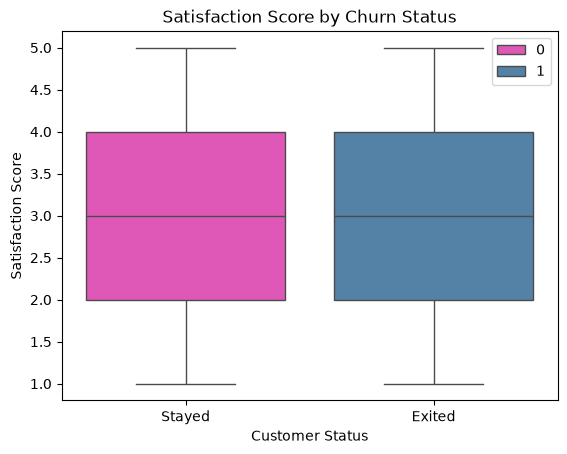

In [44]:
sns.boxplot(
    data=df,
    x="Exited",
    y="Satisfaction Score",
    hue="Exited",
    palette=["#f542c2", "steelblue"],
    legend=True
)

plt.title("Satisfaction Score by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Satisfaction Score")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.legend()
plt.show()

## 11. Churn by Complains

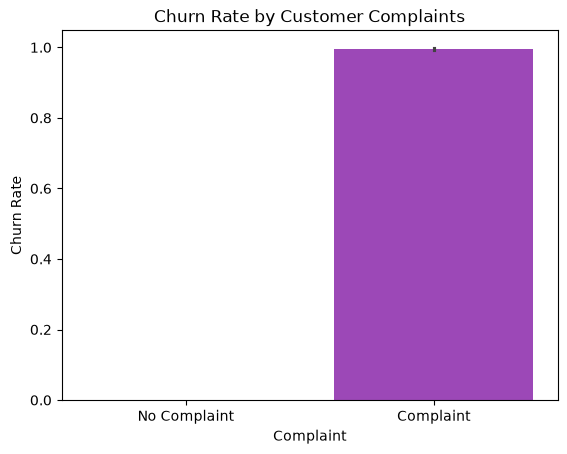

In [55]:
sns.barplot(data=df, x="Complain", y="Exited",color="#a536c9")

plt.title("Churn Rate by Customer Complaints")
plt.xlabel("Complaint")
plt.ylabel("Churn Rate")
plt.xticks([0, 1], ["No Complaint", "Complaint"])
plt.savefig("images/churn_by_complains.png")
plt.show()

## 12. Churn by Credit Score

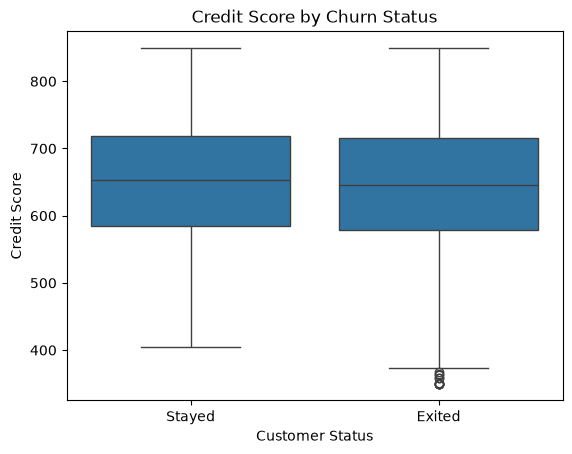

In [33]:
sns.boxplot(data=df, x="Exited", y="CreditScore")

plt.title("Credit Score by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Credit Score")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.show()

## 13. Churn Rate by balance

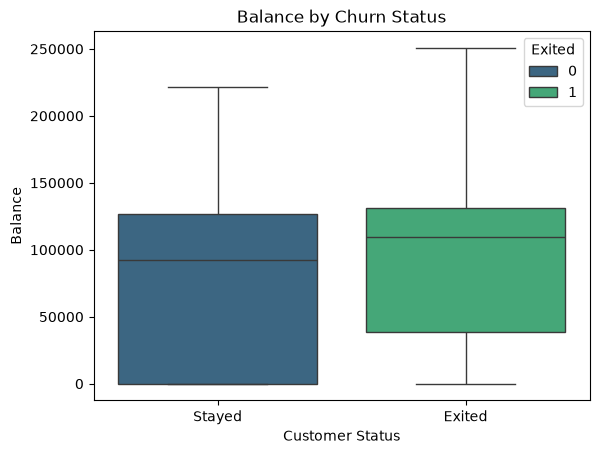

In [56]:
sns.boxplot(data=df, x="Exited", y="Balance",hue="Exited",palette="viridis")

plt.title("Balance by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Balance")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.savefig("images/churn_by_balance.png")
plt.show()

## 14. Churn by Estimated Salary

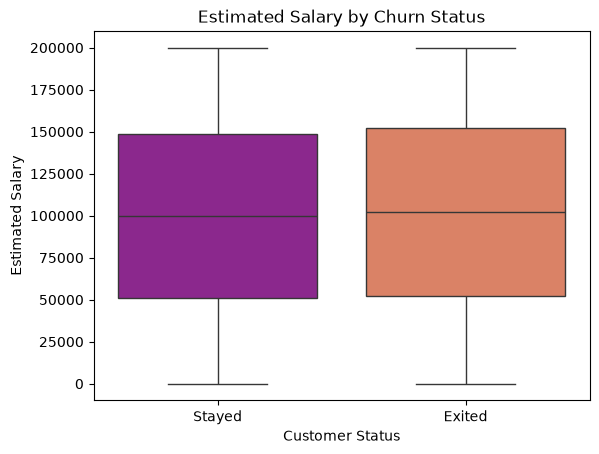

In [57]:
sns.boxplot(
    data=df,
    x="Exited",
    y="EstimatedSalary",
    hue="Exited",
    palette="plasma",
    legend=False
)

plt.title("Estimated Salary by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Estimated Salary")
plt.xticks([0, 1], ["Stayed", "Exited"])
plt.savefig("images/churn_by_salary.png")
plt.show()

In [36]:
corr=df.corr(numeric_only=True)
corr

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016140,-0.016957,0.009289,0.002360
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006203,-0.007293,-0.000865,-0.013076
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.026771,-0.027048,-0.012599,0.000077
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285296,0.283530,-0.000876,0.002222
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.013656,-0.013047,0.008663,-0.010196
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118577,0.119124,-0.002588,0.014608
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047611,-0.046357,-0.011394,-0.015330
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.006976,-0.007095,-0.000212,-0.011041
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156356,-0.154741,0.010236,-0.004983
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012490,0.012494,-0.013747,-0.001515


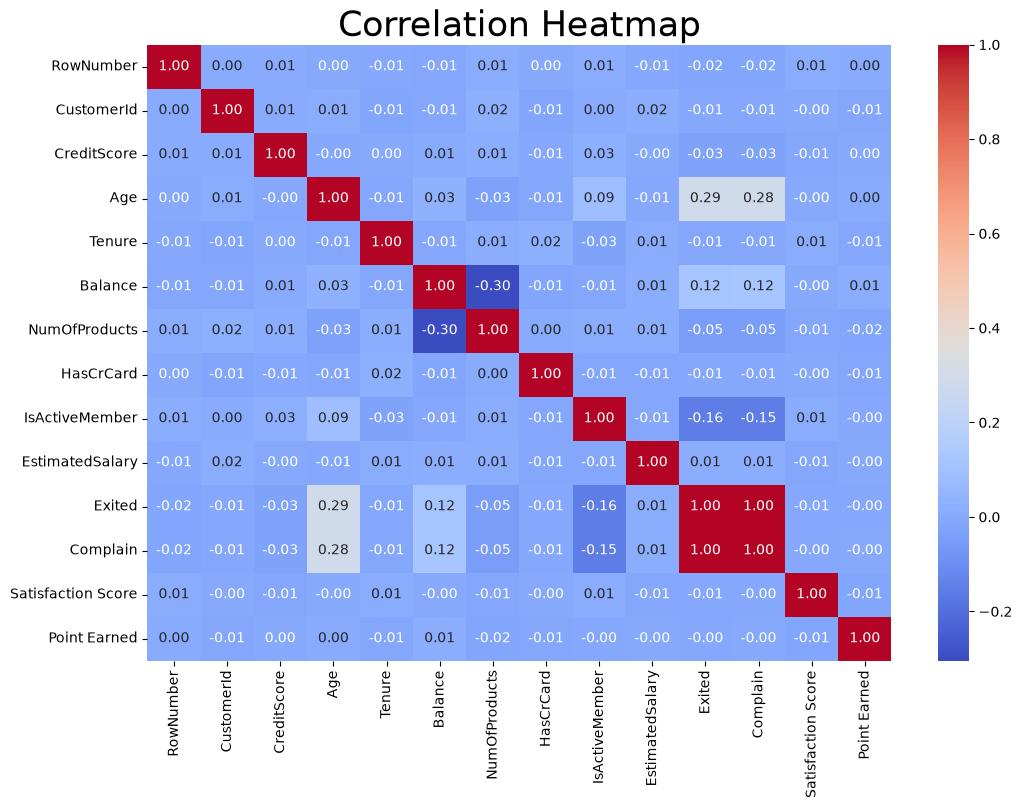

In [58]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap",fontsize=25)
plt.savefig("images/correlation_heatmap.png")
plt.show()

## Key Findings

The exploratory data analysis revealed several important patterns related to customer churn:

- Germany has the highest churn rate among the three countries, while France and Spain have considerably lower churn rates.

- Female customers have a higher churn rate than male customers in this dataset.

- Customers who exited generally have a higher age distribution than customers who stayed.

- The number of products a customer has is associated with different levels of churn. Customers with different numbers of products show noticeably different churn behavior.

- Customer activity is related to churn. Active and inactive members show different churn rates.

- Satisfaction score shows differences between customers who stayed and customers who exited.

- Customer complaints have an extremely strong association with churn. In this dataset, customers who complained were almost perfectly associated with customers who exited.

- Credit scores of stayed and exited customers have very similar distributions, suggesting that credit score does not have a strong relationship with churn in this dataset.

- Exited customers have a somewhat higher median balance than customers who stayed.

- Estimated salary distributions are very similar for stayed and exited customers, suggesting little relationship between estimated salary and churn.

- The correlation analysis supports several of these observations. Age has a positive correlation with Exited (0.29), while IsActiveMember has a negative correlation (-0.16). Balance has a weak positive correlation (0.12), while CreditScore (-0.03) and EstimatedSalary (0.01) have very weak correlations with churn.

## Conclusion

This project analyzed bank customer data to understand patterns associated with customer churn. The analysis included data cleaning, exploratory data analysis, visualization, and correlation analysis.

Several factors showed noticeable relationships with customer churn, particularly geography, age, active membership, customer complaints, satisfaction, balance, and number of products. Germany showed the highest churn rate, while estimated salary and credit score showed relatively weak relationships with churn.

The analysis provides useful insights into customer behavior and can help the bank identify customer groups that may require further investigation and targeted retention strategies.

Overall, the project demonstrates how a Data Analyst can transform raw customer data into meaningful insights that can support business decision-making.